# TP: Model Selection - Bias vs Variance

## Objectives
- Understand the bias-variance tradeoff
- Master cross-validation techniques
- Compare different types of models (linear, penalized, non-linear)
- Identify overfitting/underfitting problems

In [1]:
# Import necessary packages
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import seaborn as sns

# Display configuration
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Suppress warnings for cleaner display
import warnings
warnings.filterwarnings('ignore')

# Plot configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Data Generation

We will create a synthetic dataset to study the bias-variance tradeoff. 
The target function is: **y = sin(πx) + ε** where ε is Gaussian noise.

**Question**: Why use a sinusoidal function? What will it allow us to observe?

La fonction sinus est utilisée parce qu’elle est simple, non-linéaire et facile à visualiser.
Elle permet d’observer clairement l’effet du bruit et de comparer modèles simples (biais élevé) et complexes (variance élevée).
Ainsi, elle illustre parfaitement le compromis biais‑variance dans les prédictions.

In [2]:
# Fix random seed for reproducibility
# np.random.seed(42)
# random.seed(42)

def generate_samples(size, sigma_eps):
    x = np.linspace(0, 2, num=size)
    eps = np.random.normal(0, sigma_eps, size) 
    y = np.sin(pi * x) + eps
    return (x,y)

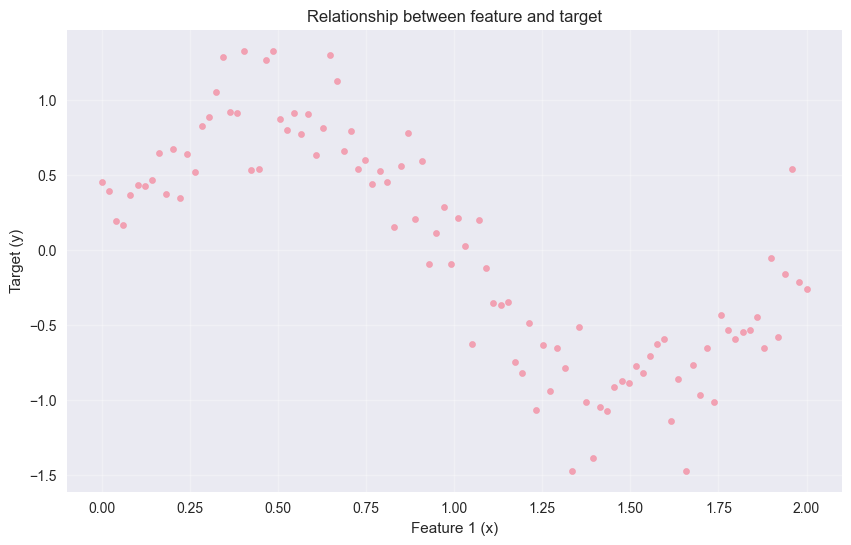

In [4]:
SIZE = 100
SIGMA_EPS = 0.25
x,y = generate_samples(SIZE, SIGMA_EPS)
# Visualization of the relationship between x and y
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=20)
plt.xlabel('Feature 1 (x)')
plt.ylabel('Target (y)')
plt.title('Relationship between feature and target')
plt.grid(True, alpha=0.3)
plt.show()

## 2. Validation Split

**Exercise**: Generate a validation set following the same distribution

In [6]:
# Create validation set
# We use the same function to get the same ditribution with 50 size 

VAL_SIZE = 50  # taille du jeu de validation
x_val, y_val = generate_samples(VAL_SIZE, SIGMA_EPS)

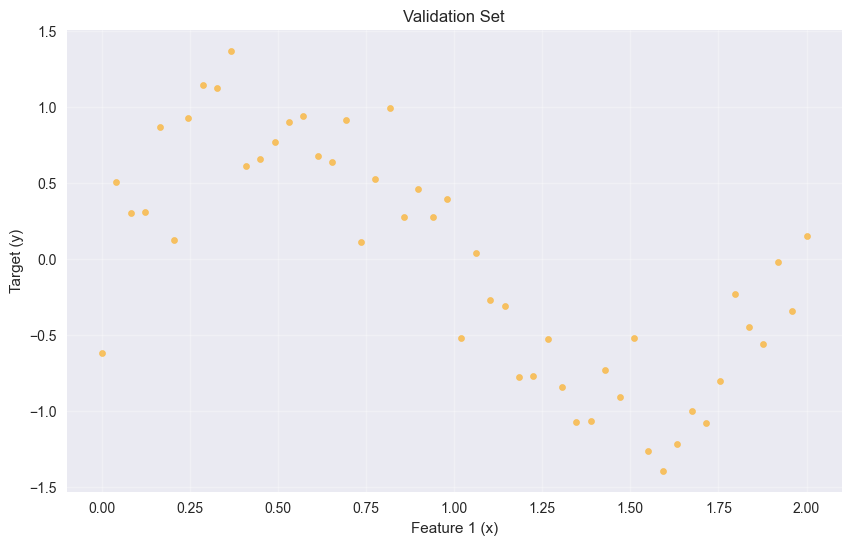

In [ ]:
# Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(x_val, y_val, alpha=0.6, s=20, color='orange')
plt.xlabel('Feature 1 (x)')
plt.ylabel('Target (y)')
plt.title('Validation Set')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# Create validation set
# We use the same function to get the same ditribution with 50 size 

TEST_SIZE = 50  # taille du jeu de validation
x_test, y_test = generate_samples(TEST_SIZE, SIGMA_EPS)

df_test =pd.DataFrame({
    "x_test" : x_test,
    "y_test" : y_test
})

df_test.head()

,x_test,y_test
0,0.000000,-0.010587
1,0.040816,0.045790
2,0.081633,-0.029496
3,0.122449,0.291314
4,0.163265,0.473603


## 3. Train/Validation Split Visualization

**Exercise**: Create a plot showing training and validation data with different colors.

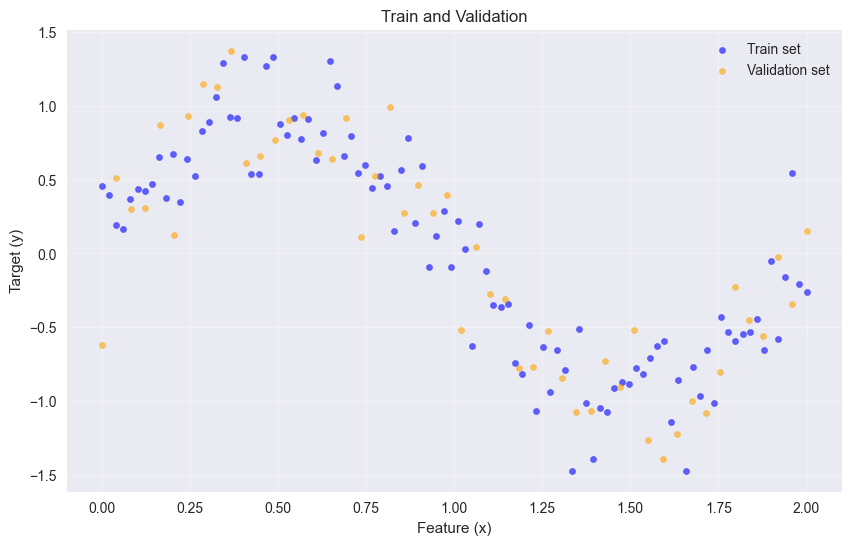

In [9]:
### 
### our code here
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.6, s=20, label='Train set') # Train set en bleu

plt.scatter(x_val, y_val, color='orange', alpha=0.6, s=20, label='Validation set')  # Validation set en orange

# Labels et titre
plt.xlabel('Feature (x)')
plt.ylabel('Target (y)')
plt.title('Train and Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

 on voit que les deux suivent la meme distribution. Mais le validation set (en orange) est moins dense.

## 4. Linear Regression

**Objective**: Implement and evaluate a simple linear regression model.

In [ ]:
from sklearn.linear_model import LinearRegression

def fit_reg_lineaire(df, features, target):
    """
    Trains a linear regression model.
    
    Arguments:
        df {dataframe} -- data dataframe
        features {list} -- list of features to include in your model
        target {str} -- target to model
    
    Returns:
        model {LinearRegression} -- trained linear model
    """
    # 1. Model creation
    model = LinearRegression()
    
    # 2. Extraire X et y
    X = df[features].values.reshape(-1, len(features))
    y = df[target].values
    
    # 3. Entraîner le modèle
    model.fit(X, y)
    
    return model


In [19]:

df = pd.DataFrame({
    'x': x,   # feature
    'y': y    # target
})

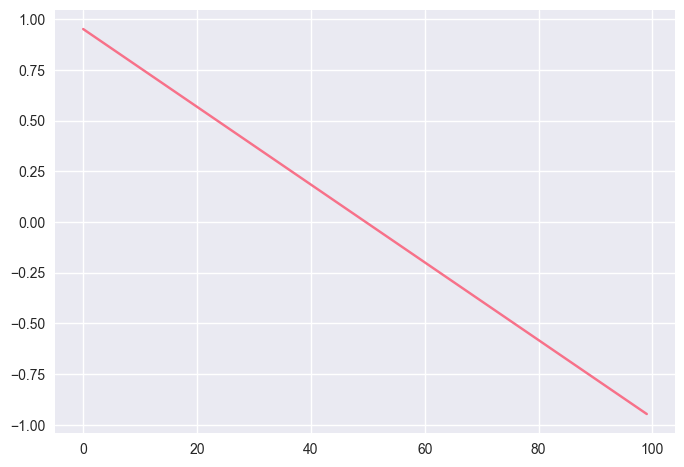

In [24]:
features = ["x"]
target = ['y']

model = fit_reg_lineaire(df, features, target)

# Prédire sur le même jeu ou sur validation
y_pred = model.predict(df[features])

plt.plot(y_pred)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def pred_evaluate_reg_lineaire(model, df_test, features, target):
    """
    Predicts and evaluates a linear regression model.
    
    Arguments:
        model {LinearRegression} -- trained linear model
        df_test {dataframe} -- data dataframe for model evaluation
        features {list} -- list of features to include in your model
        target {str} -- target
    
    Returns:
        mse {float} -- mean squared error of the model on df_test
        mae {float} -- mean absolute error of the model on df_test
    """
    # 1. Extraire X et y du jeu de test
    X_test = df_test[features]
    y_test = df_test[target]
    
    # 2. Prédictions du modèle
    y_pred = model.predict(X_test)
    
    # 3. Calcul des métriques
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    return mse, mae


In [35]:
features = ['x_test']  # liste des colonnes features
target = 'y_test'     # nom de la colonne target

mse, mae = pred_evaluate_reg_lineaire(model, df_test, features, target)

print("MSE:", mse)
print("MAE:", mae)

MSE: 0.27898585262624415
MAE: 0.4481898905583195


Training linear regression model...

Results:
Train - MSE: 0.2381, MAE: 0.4064
Val   - MSE: 0.2790, MAE: 0.4482


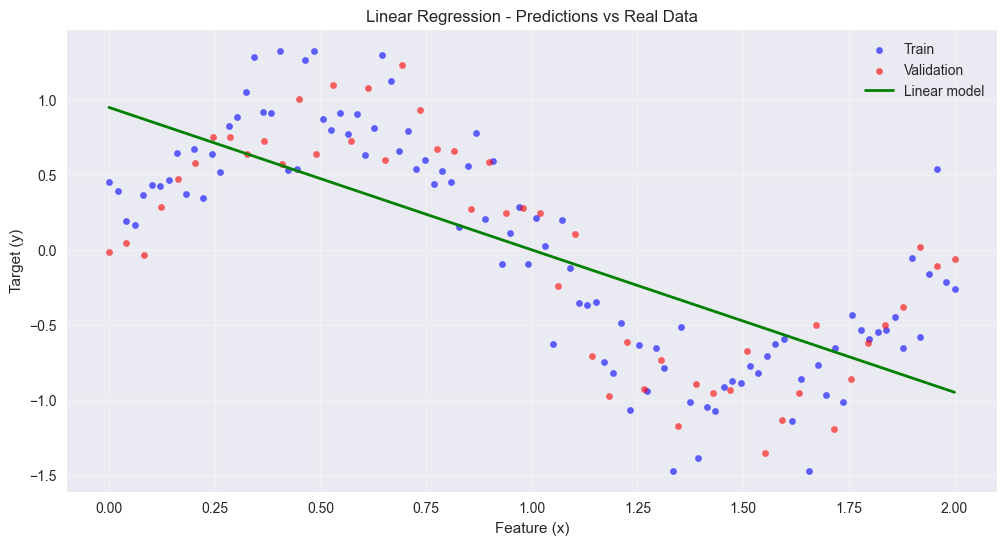

In [38]:
# Utiliser les DataFrames existants
features = ['x']       # colonne feature du train set
target = 'y'           # colonne target

# Model training
print("Training linear regression model...")
model_linear = fit_reg_lineaire(df, features, target)

# Evaluation on train and validation
mse_train, mae_train = pred_evaluate_reg_lineaire(model_linear, df, features, target)
mse_val, mae_val = pred_evaluate_reg_lineaire(model_linear, df_test, ['x_test'], 'y_test')

print(f"\nResults:")
print(f"Train - MSE: {mse_train:.4f}, MAE: {mae_train:.4f}")
print(f"Val   - MSE: {mse_val:.4f}, MAE: {mae_val:.4f}")

# Prediction visualization
plt.figure(figsize=(12, 6))

# Training data
plt.scatter(df['x'], df['y'],
           alpha=0.6, s=20, label='Train', color='blue')

# Validation data
plt.scatter(df_test['x_test'], df_test['y_test'], 
           alpha=0.6, s=20, label='Validation', color='red')

# Model predictions
x_range = np.linspace(0, 2, 100).reshape(-1, 1)
y_pred_range = model_linear.predict(pd.DataFrame({'x': x_range.flatten()}))
plt.plot(x_range, y_pred_range, 'g-', linewidth=2, label='Linear model')

plt.xlabel('Feature (x)')
plt.ylabel('Target (y)')
plt.title('Linear Regression - Predictions vs Real Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Results Analysis
**Questions to ask:**
1. Does the linear model capture the sinusoidal relationship well?
2. Is there a significant difference between train and validation error?
3. What does this tell us about the model's bias and variance?

1- Le modèle linéaire capture-t-il bien la relation sinusoidale ?

Non, clairement pas.

La ligne verte est droite alors que la vraie relation est sinusoidale.

Cela montre un biais élevé : le modèle est trop simple pour capturer la complexité des données.

2️- Différence train vs validation ?

Les erreurs sur le train et la validation semblent similaires, car la droite n’arrive pas à suivre la forme sinusoïdale.

Cela indique que le problème n’est pas l’overfitting (variance élevée), mais l’underfitting (biais élevé).

3️- Ce que cela nous dit sur bias/variance

Modèle trop simple → biais élevé

Écart faible entre train et validation → variance faible

Conclusion : il faut un modèle plus flexible (par ex. régression polynomiale) pour réduire le biais.

In [ ]:
# Polynomial regression to reduce bias
from sklearn.preprocessing import PolynomialFeatures

# Exercise: Create a polynomial evaluation function
def evaluate_poly_reg(df_train, df_test, features, target, degree_poly):
    """
    Evaluates a polynomial regression model.
    
    Arguments:
        df_train {dataframe} -- data dataframe for model training
        df_test {dataframe} -- data dataframe for model evaluation
        features {list} -- list of features to include in your model
        target {str} -- target
        degree_poly {int} -- polynomial degree
        
    Returns:
        erreur_test {float} -- mse of the model on df_test dataset
        erreur_train {float} -- mse of the model on df_train dataset
    """
    # Hint: 
    # 1. Create a PolynomialFeatures transformer with the correct degree
    # 2. Transform training and test features
    # 3. Train a linear model on transformed features
    # 4. Evaluate on train and test
    
    return None, None

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def evaluate_poly_reg(df_train, df_test, features, target, degree_poly):
    """
    Evaluates a polynomial regression model.
    
    Arguments:
        df_train {dataframe} -- data dataframe for model training
        df_test {dataframe} -- data dataframe for model evaluation
        features {list} -- list of features to include in your model
        target {str} -- target
        degree_poly {int} -- polynomial degree
        
    Returns:
        erreur_test {float} -- mse of the model on df_test dataset
        erreur_train {float} -- mse of the model on df_train dataset
    """
    # 1. Créer le transformateur polynomial
    poly = PolynomialFeatures(degree=degree_poly, include_bias=False)
    
    # 2. Transformer les features train et test
    X_train = df[features]
    y_train = df[target]
    X_train_poly = poly.fit_transform(X_train)
    
    X_test = df_test[features]
    y_test = df_test[target]
    X_test_poly = poly.transform(X_test)
    
    # 3. Entraîner le modèle linéaire sur les features polynomiales
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # 4. Prédictions et calcul des erreurs
    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)
    
    erreur_train = mean_squared_error(y_train, y_pred_train)
    erreur_test = mean_squared_error(y_test, y_pred_test)
    
    return erreur_test, erreur_train

In [44]:
# Renommer les colonnes de df_test pour matcher avec df_train
df_test_renamed = df_test.rename(columns={'x_test': 'x', 'y_test': 'y'})

# Test different polynomial degrees
print("Testing different polynomial degrees...")

features = ['x']
target = 'y'

for degree in [1, 3, 5, 10, 15]:
    mse_test, mse_train = evaluate_poly_reg(
        df, df_test_renamed, 
        features, target, 
        degree
    )
    print(f"Degree {degree:2d} - Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")

Testing different polynomial degrees...
Degree  1 - Train MSE: 0.2381, Test MSE: 0.2790
Degree  3 - Train MSE: 0.0657, Test MSE: 0.0609
Degree  5 - Train MSE: 0.0580, Test MSE: 0.0521
Degree 10 - Train MSE: 0.0541, Test MSE: 0.0535
Degree 15 - Train MSE: 0.0505, Test MSE: 0.0590


Testing polynomial degrees...
Degree  1 - Train: 0.2381, Test: 0.2790
Degree  2 - Train: 0.2371, Test: 0.2819
Degree  3 - Train: 0.0657, Test: 0.0609
Degree  5 - Train: 0.0580, Test: 0.0521
Degree  7 - Train: 0.0578, Test: 0.0537
Degree 10 - Train: 0.0541, Test: 0.0535
Degree 15 - Train: 0.0505, Test: 0.0590


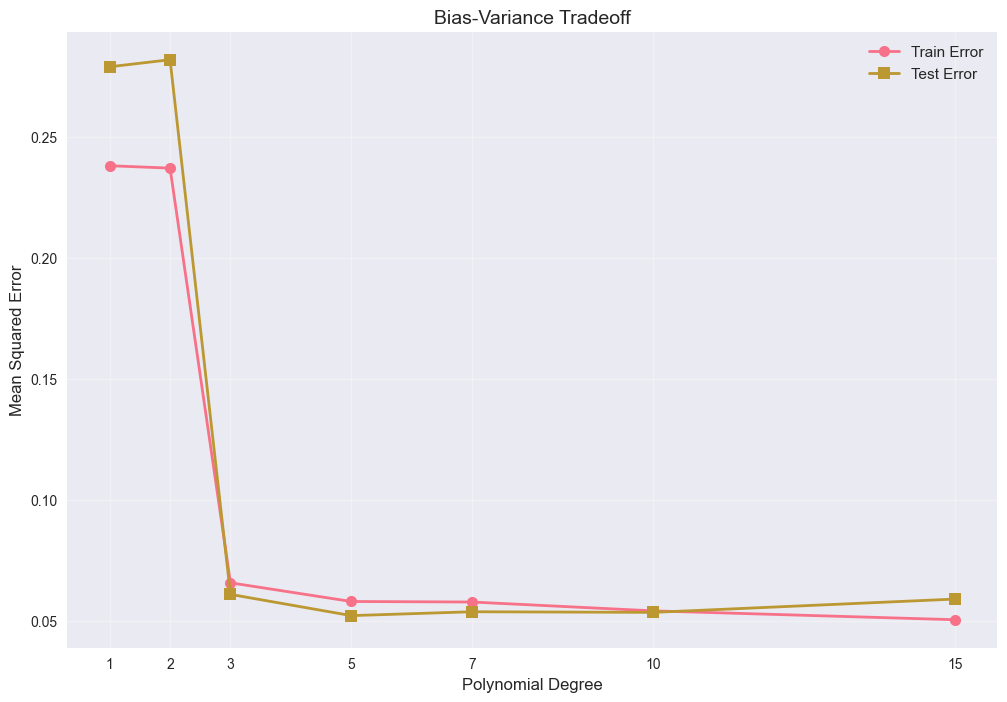

In [45]:
# Bias-variance tradeoff visualization
# PLot 2D graphs showing model errors vs Polynomial degree
plt.figure(figsize=(12, 8))

# Tester plusieurs degrés
degrees = [1, 2, 3, 5, 7, 10, 15]
train_errors = []
test_errors = []

features = ['x']
target = 'y'

print("Testing polynomial degrees...")
for degree in degrees:
    mse_test, mse_train = evaluate_poly_reg(
        df, df_test_renamed, 
        features, target, 
        degree
    )
    train_errors.append(mse_train)
    test_errors.append(mse_test)
    print(f"Degree {degree:2d} - Train: {mse_train:.4f}, Test: {mse_test:.4f}")

# Tracer les courbes
plt.plot(degrees, train_errors, 'o-', label='Train Error', linewidth=2, markersize=8)
plt.plot(degrees, test_errors, 's-', label='Test Error', linewidth=2, markersize=8)

plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Bias-Variance Tradeoff', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(degrees)
plt.show()


### Results Interpretation
**Key questions:**
1. **High bias**: At what degree does validation error start to decrease significantly?
2. **High variance**: From what degree does the gap between train and validation increase?
3. **Optimal point**: What degree minimizes validation error?

1️⃣ High bias (Underfitting) : À quel degré l'erreur de validation commence à diminuer significativement ?
Réponse : Degrés 1-2

Degré 1 et 2 : erreur de validation très élevée (~0.28)
À partir du degré 3 : l'erreur chute drastiquement (~0.06)

→ Les modèles de degré 1-2 ont un biais trop élevé, ils sont trop simples pour capturer la fonction sinusoïdale.

2️⃣ High variance (Overfitting) : À partir de quel degré l'écart entre train et validation augmente ?
Réponse : À partir du degré 10-15

Degrés 3-7 : les courbes train et test sont très proches (bon équilibre)
Degré 10+ : l'erreur de test commence à remonter légèrement pendant que le train continue de baisser

→ À partir du degré 10, le modèle commence à sur-ajuster (variance élevée).

3️⃣ Point optimal : Quel degré minimise l'erreur de validation ?
Réponse : Degré 3-5

L'erreur de test est minimale autour de degré 5 (~0.053)
Degrés 3-7 donnent tous des performances similaires et excellentes

→ Le degré optimal est ~5 : bon compromis bias-variance.

## 5. Penalized Regression (Lasso/Ridge)

**Objective**: Use regularization to control overfitting.

In [46]:
# Exercise: Implement penalized regression
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

def evaluate_regularized_reg(df_train, df_test, features, target, model_type='ridge', alpha=1.0):
    """
    Evaluates a regularized regression model.
    
    Arguments:
        df_train {dataframe} -- training data
        df_test {dataframe} -- test data
        features {list} -- list of features
        target {str} -- target
        model_type {str} -- model type ('ridge', 'lasso', 'elastic')
        alpha {float} -- regularization parameter
        
    Returns:
        mse_test, mse_train -- errors on test and train
    """
    # 1. Extraire X et y
    X_train = df_train[features]
    y_train = df_train[target]
    X_test = df_test[features]
    y_test = df_test[target]
    
    # 2. Normaliser les features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 3. Créer le modèle selon le type
    if model_type == 'ridge':
        model = Ridge(alpha=alpha)
    elif model_type == 'lasso':
        model = Lasso(alpha=alpha, max_iter=10000)
    elif model_type == 'elastic':
        model = ElasticNet(alpha=alpha, max_iter=10000)
    else:
        raise ValueError("model_type must be 'ridge', 'lasso', or 'elastic'")
    
    # 4. Entraîner le modèle
    model.fit(X_train_scaled, y_train)
    
    # 5. Prédictions et calcul des erreurs
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    
    return mse_test, mse_train


# Test with different regularization parameters
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
features = ['x']
target = 'y'

print("\n" + "="*60)
print("RIDGE REGRESSION")
print("="*60)
for alpha in alphas:
    mse_test, mse_train = evaluate_regularized_reg(
        df, df_test_renamed, features, target, 
        model_type='ridge', alpha=alpha
    )
    print(f"Alpha {alpha:6.3f} - Train: {mse_train:.6f}, Test: {mse_test:.6f}")

print("\n" + "="*60)
print("LASSO REGRESSION")
print("="*60)
for alpha in alphas:
    mse_test, mse_train = evaluate_regularized_reg(
        df, df_test_renamed, features, target, 
        model_type='lasso', alpha=alpha
    )
    print(f"Alpha {alpha:6.3f} - Train: {mse_train:.6f}, Test: {mse_test:.6f}")

print("\n" + "="*60)
print("ELASTIC NET")
print("="*60)
for alpha in alphas:
    mse_test, mse_train = evaluate_regularized_reg(
        df, df_test_renamed, features, target, 
        model_type='elastic', alpha=alpha
    )
    print(f"Alpha {alpha:6.3f} - Train: {mse_train:.6f}, Test: {mse_test:.6f}")


RIDGE REGRESSION
Alpha  0.001 - Train: 0.238091, Test: 0.278985
Alpha  0.010 - Train: 0.238091, Test: 0.278980
Alpha  0.100 - Train: 0.238092, Test: 0.278926
Alpha  1.000 - Train: 0.238121, Test: 0.278416
Alpha 10.000 - Train: 0.240625, Test: 0.276055
Alpha 100.000 - Train: 0.314724, Test: 0.326832

LASSO REGRESSION
Alpha  0.001 - Train: 0.238092, Test: 0.278877
Alpha  0.010 - Train: 0.238191, Test: 0.277992
Alpha  0.100 - Train: 0.248091, Test: 0.278230
Alpha  1.000 - Train: 0.544622, Test: 0.531041
Alpha 10.000 - Train: 0.544622, Test: 0.531041
Alpha 100.000 - Train: 0.544622, Test: 0.531041

ELASTIC NET
Alpha  0.001 - Train: 0.238092, Test: 0.278901
Alpha  0.010 - Train: 0.238151, Test: 0.278200
Alpha  0.100 - Train: 0.243565, Test: 0.276463
Alpha  1.000 - Train: 0.506295, Test: 0.495859
Alpha 10.000 - Train: 0.544622, Test: 0.531041
Alpha 100.000 - Train: 0.544622, Test: 0.531041


In [ ]:
# Apply the same steps to the penalized model

In [ ]:
# What can be concluded

### <span style="color:#011C5D">3 - Modèle Non Lineaire</span>

In [ ]:
# Reuse the linear model example, but replace the linear model with TabNet

- Lien Tabnet : https://github.com/dreamquark-ai/tabnet
- Exemple Notebook Tabnet : https://github.com/dreamquark-ai/tabnet/blob/develop/regression_example.ipynb

In [ ]:
# Apply the same steps to the non linear model

In [ ]:
# What can be concluded

## 6. Cross-Validation Strategies

**Objective**: Understand how to choose the right cross-validation strategy according to data type.

### Types of Cross-Validation

1. **K-Fold**: For independent and balanced data
2. **Stratified K-Fold**: For imbalanced data (classification)
3. **Time Series Split**: For temporal data
4. **Group K-Fold**: For grouped data (same patient, same group)
5. **Leave-One-Out**: For small samples

### Exercise: Data Analysis and Strategy Choice

**For each dataset below:**
1. **Analyze** data characteristics
2. **Choose** appropriate cross-validation strategy
3. **Apply** this strategy
4. **Visualize** data distribution by fold

#### 6.1 - Example 1: Titanic Data

#### 6.2 - Example 2: Sales Data

#### 6.3 - Example 3: Real Estate Price Data

## 7. Summary and Best Practices

1. **Bias-Variance Tradeoff**
   - High bias = underfitting (model too simple)
   - High variance = overfitting (model too complex)
   - Optimal point = balance between the two

2. **Cross-Validation Strategies**
   - **KFold**: Independent and balanced data
   - **StratifiedKFold**: Imbalanced data (classification)
   - **TimeSeriesSplit**: Temporal data
   - **GroupKFold**: Grouped data
